In [ ]:
import os, time, random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, BertForMaskedLM
from transformers import DataCollatorForLanguageModeling, Trainer, TrainingArguments, AutoTokenizer
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [ ]:
imdb = pd.read_csv('IMDB Dataset.csv')
imdb['label'] = imdb['sentiment'].map({'positive': 1, 'negative': 0})
imdb = imdb.sample(n=3000, random_state=42).reset_index(drop=True)

i_train, i_temp = train_test_split(imdb, test_size=0.30, random_state=42, stratify=imdb['label'])
i_val,   i_test = train_test_split(i_temp, test_size=0.50, random_state=42, stratify=i_temp['label'])
print(len(i_train), len(i_val), len(i_test))

2100 450 450


In [ ]:
df1 = pd.read_csv('drugsComTrain_raw.csv')
df2 = pd.read_csv('drugsComTest_raw.csv')
med = pd.concat([df1, df2], ignore_index=True)[['review','rating']].dropna()
med['label'] = (med['rating'] >= 6).astype(int)

p = med[med['label']==1].sample(n=1500, random_state=42)
n = med[med['label']==0].sample(n=1500, random_state=42)
med = pd.concat([p, n]).sample(frac=1, random_state=42).reset_index(drop=True)
med['review'] = med['review'].str.replace(r'&#[0-9]+;', ' ', regex=True)
med['review'] = med['review'].str.replace(r'<.*?>', ' ', regex=True)

m_train, m_temp = train_test_split(med, test_size=0.30, random_state=42, stratify=med['label'])
m_val,   m_test = train_test_split(m_temp, test_size=0.50, random_state=42, stratify=m_temp['label'])
print(len(m_train), len(m_val), len(m_test))

2100 450 450


In [ ]:
ML  = 128
BS  = 32

class TextDS(Dataset):
    def __init__(self, texts, labels, tok):
        self.texts  = [str(t) for t in texts]
        self.labels = labels
        self.tok    = tok

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, i):
        e = self.tok(self.texts[i], truncation=True, padding='max_length',
                     max_length=ML, return_tensors='pt')
        return {
            'input_ids':      e['input_ids'].squeeze(),
            'attention_mask': e['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[i], dtype=torch.long)
        }


def get_loaders(trdf, vadf, tedf, tok, col='review'):
    tr = TextDS(trdf[col].tolist(), trdf['label'].tolist(), tok)
    va = TextDS(vadf[col].tolist(), vadf['label'].tolist(), tok)
    te = TextDS(tedf[col].tolist(), tedf['label'].tolist(), tok)
    return (DataLoader(tr, batch_size=BS, shuffle=True,  num_workers=2, pin_memory=True),
            DataLoader(va, batch_size=BS, num_workers=2, pin_memory=True),
            DataLoader(te, batch_size=BS, num_workers=2, pin_memory=True))


bert_tok = BertTokenizer.from_pretrained('bert-base-uncased')
i_tr, i_va, i_te = get_loaders(i_train, i_val, i_test, bert_tok)
m_tr, m_va, m_te = get_loaders(m_train, m_val, m_test, bert_tok)
print('loaders ready')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

loaders ready


In [ ]:
def train_one(model, loader, opt, dev):
    model.train()
    total = 0
    for b in loader:
        ids  = b['input_ids'].to(dev)
        mask = b['attention_mask'].to(dev)
        lab  = b['labels'].to(dev)
        opt.zero_grad()
        out  = model(input_ids=ids, attention_mask=mask, labels=lab)
        out.loss.backward()
        opt.step()
        total += out.loss.item()
    return total / len(loader)


def evaluate(model, loader, dev):
    model.eval()
    preds, labs = [], []
    with torch.no_grad():
        for b in loader:
            out = model(input_ids=b['input_ids'].to(dev),
                        attention_mask=b['attention_mask'].to(dev))
            preds.extend(torch.argmax(out.logits, 1).cpu().numpy())
            labs.extend(b['labels'].numpy())
    return accuracy_score(labs, preds), f1_score(labs, preds, average='macro'), preds, labs


def get_size(model):
    n = sum(p.numel() for p in model.parameters())
    return n, round(n * 4 / 1024**2, 2)

In [ ]:
baseline = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
baseline.to(device)
opt_b = torch.optim.AdamW(baseline.parameters(), lr=2e-5)

t0 = time.time()
for ep in range(1, 4):
    loss = train_one(baseline, i_tr, opt_b, device)
    acc, f1, _, _ = evaluate(baseline, i_va, device)
    print(f'ep{ep}  loss={loss:.4f}  acc={acc:.4f}  f1={f1:.4f}')
baseline_time = time.time() - t0

b_acc_imdb, b_f1_imdb, _, _ = evaluate(baseline, i_te, device)
b_acc_med,  b_f1_med,  _, _ = evaluate(baseline, m_te, device)
bp, bsz = get_size(baseline)

print(f'IMDb  acc={b_acc_imdb:.4f} f1={b_f1_imdb:.4f}')
print(f'Med   acc={b_acc_med:.4f}  f1={b_f1_med:.4f}')
print(f'params={bp:,}  size={bsz}MB  time={baseline_time:.1f}s')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ep1  loss=0.5760  acc=0.8200  f1=0.8189
ep2  loss=0.3164  acc=0.8400  f1=0.8395
ep3  loss=0.1630  acc=0.8667  f1=0.8663
IMDb  acc=0.8533 f1=0.8530
Med   acc=0.7489  f1=0.7478
params=109,483,778  size=417.65MB  time=135.9s


In [ ]:
class MLMDS(Dataset):
    def __init__(self, texts, tok):
        self.enc = tok([str(t) for t in texts], truncation=True,
                       padding='max_length', max_length=ML,
                       return_special_tokens_mask=True)

    def __len__(self):
        return len(self.enc['input_ids'])

    def __getitem__(self, i):
        return {k: torch.tensor(v[i]) for k, v in self.enc.items()}


mlm_ds   = MLMDS(m_train['review'].tolist(), bert_tok)
collator = DataCollatorForLanguageModeling(tokenizer=bert_tok, mlm=True, mlm_probability=0.15)
mlm_mdl  = BertForMaskedLM.from_pretrained('bert-base-uncased')

mlm_args = TrainingArguments(
    output_dir='./mlm_out',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    save_strategy='no',
    logging_steps=50,
    report_to='none',
    fp16=torch.cuda.is_available(),
    seed=42,
    dataloader_drop_last=True,
    dataloader_num_workers=2
)

trainer = Trainer(model=mlm_mdl, args=mlm_args,
                  train_dataset=mlm_ds, data_collator=collator)

t_mlm = time.time()
trainer.train()
mlm_time = time.time() - t_mlm

mlm_mdl.save_pretrained('./med_adapted')
bert_tok.save_pretrained('./med_adapted')
print(f'mlm done {mlm_time:.1f}s')

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Step,Training Loss
50,2.377610
100,2.193779
150,2.074260


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

mlm done 51.5s


In [ ]:
adapted = BertForSequenceClassification.from_pretrained('./med_adapted', num_labels=2,
                                                         ignore_mismatched_sizes=True)
adapted.to(device)
opt_a = torch.optim.AdamW(adapted.parameters(), lr=2e-5)

t1 = time.time()
for ep in range(1, 4):
    loss = train_one(adapted, m_tr, opt_a, device)
    acc, f1, _, _ = evaluate(adapted, m_va, device)
    print(f'ep{ep}  loss={loss:.4f}  acc={acc:.4f}  f1={f1:.4f}')
adapted_ft = time.time() - t1
adapted_total = mlm_time + adapted_ft

a_acc, a_f1, _, _ = evaluate(adapted, m_te, device)
ap, asz = get_size(adapted)

print(f'acc={a_acc:.4f}  f1={a_f1:.4f}')
print(f'params={ap:,}  size={asz}MB  time={adapted_total:.1f}s')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ./med_adapted
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ep1  loss=0.5776  acc=0.7978  f1=0.7976
ep2  loss=0.3253  acc=0.8267  f1=0.8266
ep3  loss=0.1640  acc=0.8267  f1=0.8261
acc=0.8156  f1=0.8146
params=109,483,778  size=417.65MB  time=204.8s


In [ ]:
bio_tok = AutoTokenizer.from_pretrained('dmis-lab/biobert-base-cased-v1.1')
b_tr, b_va, b_te = get_loaders(m_train, m_val, m_test, bio_tok)

biobert = BertForSequenceClassification.from_pretrained('dmis-lab/biobert-base-cased-v1.1', num_labels=2)
biobert.to(device)
opt_bio = torch.optim.AdamW(biobert.parameters(), lr=2e-5)

t2 = time.time()
for ep in range(1, 4):
    loss = train_one(biobert, b_tr, opt_bio, device)
    acc, f1, _, _ = evaluate(biobert, b_va, device)
    print(f'ep{ep}  loss={loss:.4f}  acc={acc:.4f}  f1={f1:.4f}')
bio_time = time.time() - t2

bio_acc, bio_f1, _, _ = evaluate(biobert, b_te, device)
biop, biosiz = get_size(biobert)

print(f'acc={bio_acc:.4f}  f1={bio_f1:.4f}')
print(f'params={biop:,}  size={biosiz}MB  time={bio_time:.1f}s')

config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

ep1  loss=0.6037  acc=0.7667  f1=0.7663
ep2  loss=0.3837  acc=0.8133  f1=0.8132
ep3  loss=0.2310  acc=0.8111  f1=0.8110
acc=0.8422  f1=0.8422
params=108,311,810  size=413.18MB  time=160.2s


In [ ]:
rows = [
    ['Baseline BERT (IMDb)',          b_acc_med, b_f1_med,  round(baseline_time,1),  bsz],
    ['Domain-Adapted BERT (MLM+FT)',  a_acc,     a_f1,      round(adapted_total,1),  asz],
    ['BioBERT',                        bio_acc,   bio_f1,    round(bio_time,1),        biosiz],
]
summary = pd.DataFrame(rows, columns=['Model','Accuracy','F1','Time(s)','Size(MB)'])
print(summary.to_string(index=False))

                       Model  Accuracy       F1  Time(s)  Size(MB)
        Baseline BERT (IMDb)  0.748889 0.747842    135.9    417.65
Domain-Adapted BERT (MLM+FT)  0.815556 0.814558    204.8    417.65
                     BioBERT  0.842222 0.842221    160.2    413.18


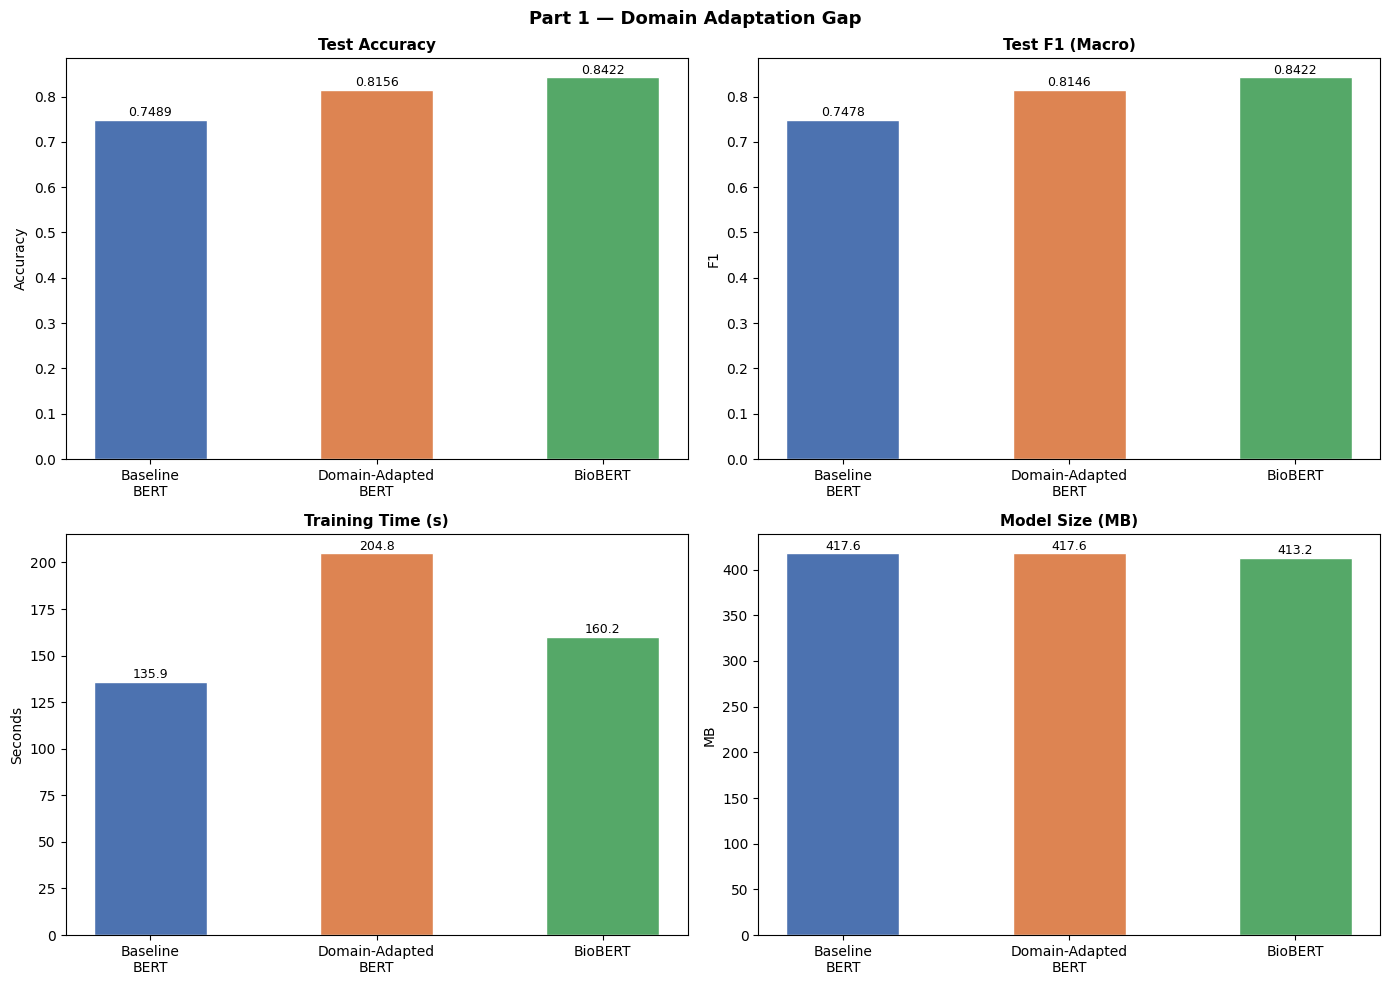

In [ ]:
names  = ['Baseline\nBERT', 'Domain-Adapted\nBERT', 'BioBERT']
accs   = [b_acc_med, a_acc,  bio_acc]
f1s    = [b_f1_med,  a_f1,   bio_f1]
times  = [baseline_time, adapted_total, bio_time]
sizes  = [bsz, asz, biosiz]
clrs   = ['#4C72B0','#DD8452','#55A868']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, vals, ttl, yl in zip(
    axes.flat,
    [accs, f1s, times, sizes],
    ['Test Accuracy','Test F1 (Macro)','Training Time (s)','Model Size (MB)'],
    ['Accuracy','F1','Seconds','MB']
):
    bars = ax.bar(names, vals, color=clrs, width=0.5, edgecolor='white')
    ax.set_title(ttl, fontsize=11, fontweight='bold')
    ax.set_ylabel(yl)
    for b in bars:
        lbl = f"{b.get_height():.4f}" if yl in ('Accuracy','F1') else f"{b.get_height():.1f}"
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+max(vals)*0.01,
                lbl, ha='center', fontsize=9)

plt.suptitle('Part 1 — Domain Adaptation Gap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
_, _, bp2, bl2 = evaluate(baseline, m_te, device)
_, _, ap2, al2 = evaluate(adapted,  m_te, device)
_, _, bp3, bl3 = evaluate(biobert,  b_te, device)

print(classification_report(bl2, bp2, target_names=['Negative','Positive']))
print(classification_report(al2, ap2, target_names=['Negative','Positive']))
print(classification_report(bl3, bp3, target_names=['Negative','Positive']))

              precision    recall  f1-score   support

    Negative       0.79      0.68      0.73       225
    Positive       0.72      0.81      0.76       225

    accuracy                           0.75       450
   macro avg       0.75      0.75      0.75       450
weighted avg       0.75      0.75      0.75       450

              precision    recall  f1-score   support

    Negative       0.87      0.74      0.80       225
    Positive       0.78      0.89      0.83       225

    accuracy                           0.82       450
   macro avg       0.82      0.82      0.81       450
weighted avg       0.82      0.82      0.81       450

              precision    recall  f1-score   support

    Negative       0.84      0.84      0.84       225
    Positive       0.84      0.84      0.84       225

    accuracy                           0.84       450
   macro avg       0.84      0.84      0.84       450
weighted avg       0.84      0.84      0.84       450

